<a href="https://colab.research.google.com/github/raflidzaky/one-piece-image-classifier/blob/master/Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
import os
import zipfile
import shutil
import time

In [ ]:
# Install Kaggle API Client
!pip install -q kaggle

In [ ]:
# Create kaggle folder
!mkdir /content/kaggle

In [ ]:
# Move the kaggle.json copy to kaggle folder
!cp kaggle.json /content/kaggle

In [ ]:
# Set permission
!chmod 600 /content/kaggle/kaggle.json

In [ ]:
# Install dataset
! kaggle datasets download -d ibrahimserouis99/one-piece-image-classifier

Dataset URL: https://www.kaggle.com/datasets/ibrahimserouis99/one-piece-image-classifier
License(s): GPL-2.0
 99% 2.51G/2.53G [00:16<00:00, 138MB/s]
100% 2.53G/2.53G [00:16<00:00, 161MB/s]


In [ ]:
with zipfile.ZipFile('/content/one-piece-image-classifier.zip', 'r') as zip_ref:
  zip_ref.extractall('/content/image_folder')

In [ ]:
image_path = '/content/image_folder/Data/Data'
class_name = '/content/image_folder/classnames.txt'

with open(class_name, 'r') as f:
  classnames = [line.strip() for line in f.readlines()]

print(classnames)
print(f'Total classes are {len(classnames)}')

['Ace', 'Akainu', 'Brook', 'Chopper', 'Crocodile', 'Franky', 'Jinbei', 'Kurohige', 'Law', 'Luffy', 'Mihawk', 'Nami', 'Rayleigh', 'Robin', 'Sanji', 'Shanks', 'Usopp', 'Zoro']
Total classes are 18


In [ ]:
def rename_files_in_folder(folder_path, class_name):
    for count, filename in enumerate(os.listdir(folder_path), start=1):
        if filename.endswith('.jpg'):
            new_filename_jpg = f"{class_name.lower()}_{count}.jpg"
            old_file_jpg = os.path.join(folder_path, filename)
            new_file_jpg = os.path.join(folder_path, new_filename_jpg)
            os.rename(old_file_jpg, new_file_jpg)

        elif filename.endswith('.png'):
            new_filename_png = f"{class_name.lower()}_{count}.png"
            old_file_png = os.path.join(folder_path, filename)
            new_file_png = os.path.join(folder_path, new_filename_png)
            os.rename(old_file_png, new_file_png)

        elif filename.endswith('.jpeg'):
            new_filename_jpeg = f"{class_name.lower()}_{count}.jpeg"
            old_file_jpeg = os.path.join(folder_path, filename)
            new_file_jpeg = os.path.join(folder_path, new_filename_jpeg)
            os.rename(old_file_jpeg, new_file_jpeg)

        else:
            pass

In [ ]:
# Rename the files to a proper naming (label + count + extension)
for class_name in classnames:
    folder_path = os.path.join(image_path, class_name)
    if os.path.exists(folder_path):
        rename_files_in_folder(folder_path, class_name)
    else:
        raise print(f"Folder '{folder_path}' tidak ditemukan.")

In [ ]:
# Create a dir to save the migrated data from {label}-subfolder
!mkdir -p /content/image_folder/Data/temporary_dir

In [ ]:
# Move the files to temporary_dir, before move it to train, test, and val dir
destin_path = '/content/image_folder/Data/temporary_dir'

def move_img_files(*, path, label, dest):
  for class_name in label:
    folder_path = os.path.join(path, class_name)

    for i in os.listdir(folder_path):
      if os.path.exists(folder_path):
        img_file = os.path.join(folder_path, i)
        shutil.move(img_file, dest)
      else:
        raise print("Cannot move the image file as it doesnt exist")

move_img_files(path=image_path,
               label=classnames,
               dest=destin_path
               )

In [ ]:
# Create train, test, and val dir
!mkdir -p /content/image_folder/Data/train
!mkdir -p /content/image_folder/Data/test
!mkdir -p /content/image_folder/Data/val

In [ ]:
# Move each respective image files to each folders
# With randomized splitting

all_images = os.listdir(destin_path)
all_images = [img for img in all_images]

train_path = '/content/image_folder/Data/train'
test_path  = '/content/image_folder/Data/test'
val_path   = '/content/image_folder/Data/val'

# Suffle the image, so that every class has roughly the same probability
# to enter each train, test, val folder
np.random.seed(42)  # For reproducibility
np.random.shuffle(all_images)

# Calculate split sizes
total_images = len(all_images)
test_size = int(total_images * 0.01)
val_size = int(total_images * 0.09)
train_size = total_images - test_size - val_size

# Split the images
test_images = all_images[:test_size]
val_images = all_images[test_size:test_size + val_size]
train_images = all_images[test_size + val_size:]

# Function to move images to a specified folder
def move_images(image_list, dest_folder):
    for img in image_list:
        src = os.path.join(destin_path, img)
        dst = os.path.join(dest_folder, img)
        shutil.move(src, dst)

# Move the images to their respective folders
move_images(test_images, test_path)
move_images(val_images, val_path)
move_images(train_images, train_path)

# Process Image Files

In [ ]:
# As the ImageFolder implies that the root path needs classes within,
# I tried to make classes-subdir within the train, test, and val path
# See: https://pytorch.org/docs/0.3.0/torchvision/datasets.html#imagefolder

# Create directories for each class in train, val, and test folders
for class_name in classnames:
    os.makedirs(os.path.join(train_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_path, class_name), exist_ok=True)

# Function to move images to respective class folders
def move_images_to_class_folders(image_list, dest_folder):
    for img in image_list:
        # Extract class name from filename
        class_name = img.split('_')[0].capitalize()  # Capitalize to match class names
        if class_name in classnames:
            src = os.path.join(dest_folder, img)
            dst = os.path.join(dest_folder, class_name, img)
            shutil.move(src, dst)
        else:
            print(f"Class '{class_name}' not found for image '{img}'")

# Move images to their respective folders
move_images_to_class_folders(test_images, test_path)

In [ ]:
move_images_to_class_folders(train_images, train_path)
move_images_to_class_folders(val_images, val_path)

In [ ]:
# I not do some center crop, because the position of the character's facial feature is different
# Yet, they have almost similar body structure (six pack XD)
# Hence, it may cause bigger loss if I do center crop

data_transforms = transforms.Compose([transforms.ToTensor(),
                                      transforms.Resize((100, 100), antialias=True),
                                      transforms.RandomVerticalFlip(),
                                      # Homogenize the color (since there also inverted image color)
                                      transforms.Grayscale(num_output_channels=3),
                                      transforms.Normalize((0.5,),
                                                           (0.5,)
                                                          )
                                     ])

val_test_transforms = transforms.Compose([transforms.ToTensor(),
                                          transforms.Resize((100, 100), antialias=True),
                                          transforms.Grayscale(num_output_channels=3),
                                          transforms.Normalize((0.5,),
                                                               (0.5,)
                                                              )
                                         ])

In [ ]:
# Transform and Load Dataset
train_datasets = datasets.ImageFolder(root=train_path,
                                      transform=data_transforms)
test_datasets  = datasets.ImageFolder(root=test_path,
                                      transform=val_test_transforms)
val_datasets   = datasets.ImageFolder(root=val_path,
                                      transform=val_test_transforms)

In [ ]:
from torch.utils.data import DataLoader

# Define DataLoader for training, validation, and testing
# This is done because ImageFolder doesn't have any batches placeholder
# While for computation-efficiency, I need Mini-Batch Grad Descent
# Anyway, I dont use pin memory because of memory limitation

train_loader = DataLoader(dataset=train_datasets, batch_size=64, shuffle=True)
val_loader = DataLoader(dataset=val_datasets, batch_size=64, shuffle=False)
test_loader = DataLoader(dataset=test_datasets, batch_size=64, shuffle=False)


In [ ]:
# Confirming classes and dataset samples
print("Number of samples in train_datasets:", len(train_datasets))
print("Classes in train_datasets:", train_datasets.classes)

Number of samples in train_datasets: 10564
Classes in train_datasets: ['Ace', 'Akainu', 'Brook', 'Chopper', 'Crocodile', 'Franky', 'Jinbei', 'Kurohige', 'Law', 'Luffy', 'Mihawk', 'Nami', 'Rayleigh', 'Robin', 'Sanji', 'Shanks', 'Usopp', 'Zoro']


In [ ]:
# Confirming images and labels shape
image, label = next(iter(train_loader))
print(image.shape)
print(label.shape) # 64 labels, match with 64 images

torch.Size([64, 3, 100, 100])
torch.Size([64])


In [ ]:
# Confirming images and labels shape
image, label = next(iter(val_loader))
print(image.shape)
print(label.shape) # 64 labels, match with 64 images

torch.Size([64, 3, 100, 100])
torch.Size([64])


# Build Deep Learning Architecture

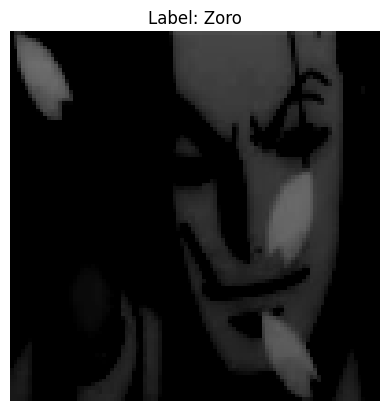

In [ ]:
# Since I want to know how the transformation works in the image
# I want to display an image

# Transform to numpy array for visualization
def tensor_to_numpy(tensor):
    if tensor.dim() == 3:  # For single-channel or multi-channel images
      tensor = tensor.permute(1, 2, 0)
    return tensor.numpy()

def display_random_image(dataset):
    # Get a random index
    index = np.random.randint(0, len(dataset) + 1)

    # Retrieve the image and label
    image, label = dataset[index]

    # Convert image to numpy array and clip values to be in the range [0, 1]
    image = tensor_to_numpy(image)
    image = np.clip(image, 0, 1)

    # Plot the image
    plt.imshow(image)
    plt.title(f'Label: {dataset.classes[label]}')
    plt.axis('off')  # Hide axes
    plt.show()

# Display a random image from train datasets
display_random_image(train_datasets)

## Model 1: Base Model
Modified basic Convolutional Neural Network. CNN is a very useful architecture to extract feature of image. Using convolution-mechanism, it extracts basic features of the image for the fully-connected layers to infer.

To prevent overfitting on training, I use Dropout with equal probability amongst neurons. The output layer has 18 neurons (representing 18 labels to predict).

I also use ADAM Optimizer because it has momentum on its equation to update weights

In [ ]:
model = torch.nn.Sequential(
                            # Feature extraction layers
                            torch.nn.Conv2d(in_channels=3, out_channels=8,
                                            kernel_size=3, stride=1, padding=1),
                            torch.nn.ReLU(),
                            torch.nn.Conv2d(in_channels=8, out_channels=16,
                                            kernel_size=3, stride=1, padding=1),
                            torch.nn.ReLU(),

                            # Reduce the dimensionality (pixels)
                            torch.nn.MaxPool2d(kernel_size=4, stride=4),

                            # This line is to make previous 2D tensors as 1D
                            # Hence, we do not need to reshape the input in training epochs.
                            torch.nn.Flatten(),

                            # Fully-connected layers
                            torch.nn.Linear(16 * 25 * 25, 1000),
                            torch.nn.ReLU(),
                            torch.nn.Dropout(p=0.5),
                            torch.nn.Linear(1000, 100),
                            torch.nn.ReLU(),
                            torch.nn.Dropout(p=0.5),
                            torch.nn.Linear(100, 18),
                            torch.nn.ReLU(),
                            torch.nn.LogSoftmax(dim=1)
                           )

In [ ]:
loss_func = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=0.00001,
                             betas=(0.9, 0.999),
                             weight_decay=0.0001
                           )
# Train from scratch pakai ADAM aja deh

# Model 11 jelek, pakai 12 or 13 ajaa...

Without model.train(), the code below is by default doing training process... Since there is GPU limitation, I need to stop training after 3700 seconds (and save the model)

In [ ]:
# Train the model
# I want to show the model weight's update and its losses

# I need this info to save the model later
# Modelnya adaptasi, jadi yaa okay lah ya. Dari 2.30-an ke 2.90 lagii
train_losses = []
val_losses = []

num_epoch = 30
start = time.time()
for e in range(num_epoch):
    init_loss = 0
    val_loss = 0
    for images, labels in train_loader:
        # Predict
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_func(logits, labels)

        # Doing gradient descent stuff
        loss.backward()
        model[0].weight.grad
        optimizer.step()

        # Append the error and print it
        init_loss = init_loss + loss
        train_losses.append(init_loss)

    # Doing validation right after process the weights on each iterations (epoch)
    model.eval()

    # Ensure the model TO NOT DOES GRADIENT DESCENT
    with torch.no_grad():
      for images, labels in val_loader:
        logits = model(images)
        loss = loss_func(logits, labels)

        val_loss += loss.item()
        val_losses.append(val_loss)

    print(f"\nTraining loss: {init_loss/len(train_loader)}, Validation loss: {val_loss/len(val_loader)}")
    end = time.time()
    if end-start > 3700:
      torch.save({
            # Create a dict as an identifier
            'model_state_dict': model.state_dict(),
            'optim_state_dict': optimizer.state_dict(),
            # Epoch information to continue retrain up to 16 epochs
            # Checkpoint epochs
            'epochs': e+1,
            # I want this as monitoring progress
            'train_loss': train_losses
            },
          'model_v16.pth')

In [ ]:
model.eval()
with torch.no_grad():
  test_acc = 0
  total_samples = 0
  test_losses = 0
  for images, labels in test_loader:
        logits = model(images)
        loss = loss_func(logits, labels)

        #Calculate accuracy
        top_r, top_k = logits.topk(1, dim=1)
        # Calculate the correct prediction while reshape the labels
        correct = (top_k == labels.view(top_k.shape[0], 1))
        float_correct = correct.type(torch.float)
        test_acc += float_correct.sum().item()
        total_samples += labels.size(0)

        # Calculate loss
        test_losses += loss

  # Report the result
  print(f"\nTest loss: {test_losses/len(test_loader)}, Test accuracy: {test_acc/total_samples}")


Test loss: 0.5886030793190002, Test accuracy: 0.811965811965812


In [ ]:
# Save model
# This dict helps me to reconstruct the model and optimizers in production-code
torch.save({
            # Create a dict as an identifier
            'model_state_dict': model.state_dict(),
            'optim_state_dict': optimizer.state_dict(),
            # Epoch information to continue retrain up to 16 epochs
            # Checkpoint epochs
            'epochs': num_epoch,
            # I want this as monitoring progress
            'train_loss': train_losses
            },
          'model_v16.pth')

In [ ]:
# Load the saved model
checkpoint = torch.load('model_v16.pth', weights_only=True)

# Load the state dictionaries
model.load_state_dict(checkpoint['model_state_dict'], strict=False)
optimizer.load_state_dict(checkpoint['optim_state_dict'])

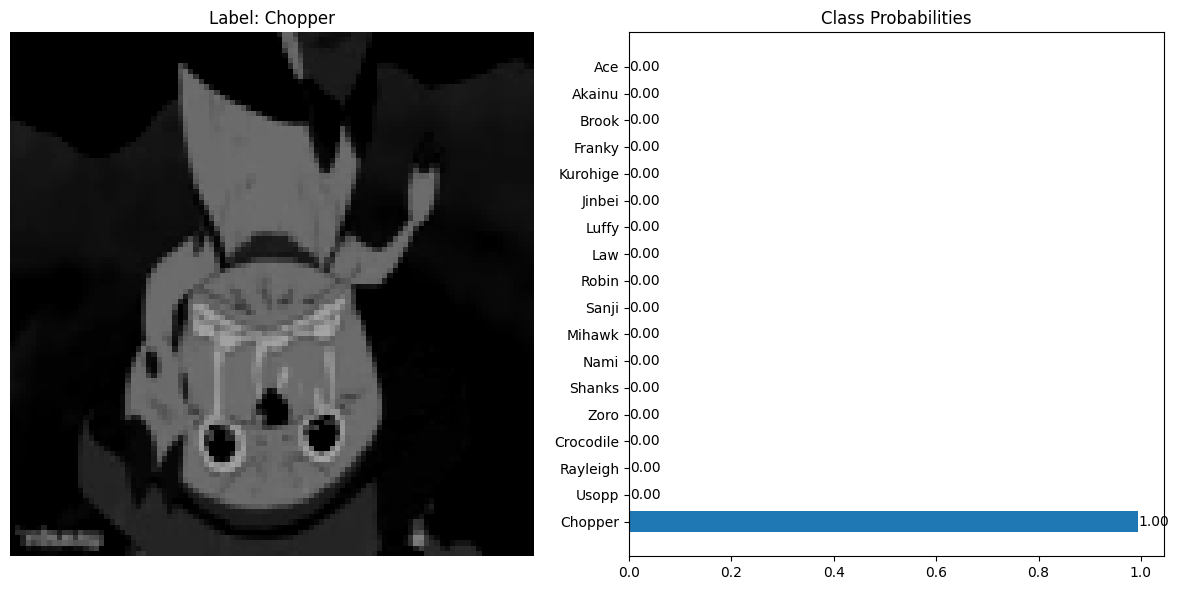

In [ ]:
def display_random_image_class(model, dataset, transform):
    # Get a random index
    index = np.random.randint(0, len(dataset))

    # Retrieve the image and label
    image, label = dataset[index]

    # Prepare the image for model input
    image = image.unsqueeze(0)  # Add batch dimension

    # Predict
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        logits = model(image)  # Get logits
        ps = torch.nn.functional.softmax(logits, dim=1).squeeze().numpy()  # Compute probabilities

    sorted_indices = np.argsort(ps)[::-1]  # Indices for sorting probabilities in descending order
    sorted_probs = ps[sorted_indices]
    sorted_labels = [dataset.classes[i] for i in sorted_indices]

    # Convert image to numpy array and clip values to be in the range [0, 1]
    image_restandard = (image + 0.5) * 0.5
    image = tensor_to_numpy(image_restandard.squeeze())  # Remove batch dimension and convert
    image = np.clip(image, 0, 1)

    # Plot the image and class probabilities
    fig, axes = plt.subplots(figsize=(12, 6), ncols=2)

    # Display the image
    axes[0].imshow(image)
    axes[0].set_title(f'Label: {dataset.classes[label]}')
    axes[0].axis('off')  # Hide axes

    # Display the class probabilities
    axes[1].barh(np.arange(len(sorted_probs)), sorted_probs)
    axes[1].set_yticks(np.arange(len(sorted_probs)))
    axes[1].set_yticklabels(sorted_labels)
    axes[1].set_title('Class Probabilities')

    for i in range(len(sorted_probs)):
        axes[1].text(sorted_probs[i], i, f'{sorted_probs[i]:.2f}', ha='left', va='center')

    plt.tight_layout()
    plt.show()

display_random_image_class(model, train_datasets, data_transforms)